In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("email_notification_logs.csv")

In [3]:
df.head()

,Log_ID,Timestamp,Service_Name,Notification_Type,Recipient_Type,Status,Failure_Reason,Response_Code,Retry_Count,Delivery_Time_ms
0,LOG00001,2026-05-05 03:56:41,Email Gateway,Email,Vendor,Delivered,NaN,250,0,389
1,LOG00002,2026-05-12 09:38:53,Authentication Service,Email,Admin,Failed,Invalid Email,550,1,4939
2,LOG00003,2026-04-27 21:36:38,Email Gateway,Alert,Employee,Delivered,NaN,250,0,1039
3,LOG00004,2026-02-12 19:19:39,Billing Service,Alert,Vendor,Delivered,NaN,250,0,506
4,LOG00005,2026-05-16 13:33:55,Billing Service,Invoice,Vendor,Delivered,NaN,250,1,869


In [4]:
df.shape

(12000, 10)

In [5]:
df.columns

Index(['Log_ID', 'Timestamp', 'Service_Name', 'Notification_Type',
       'Recipient_Type', 'Status', 'Failure_Reason', 'Response_Code',
       'Retry_Count', 'Delivery_Time_ms'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Log_ID             12000 non-null  object
 1   Timestamp          12000 non-null  object
 2   Service_Name       12000 non-null  object
 3   Notification_Type  12000 non-null  object
 4   Recipient_Type     12000 non-null  object
 5   Status             12000 non-null  object
 6   Failure_Reason     993 non-null    object
 7   Response_Code      12000 non-null  int64 
 8   Retry_Count        12000 non-null  int64 
 9   Delivery_Time_ms   12000 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 937.6+ KB


In [7]:
df.isnull().sum()

Log_ID                   0
Timestamp                0
Service_Name             0
Notification_Type        0
Recipient_Type           0
Status                   0
Failure_Reason       11007
Response_Code            0
Retry_Count              0
Delivery_Time_ms         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Status"].value_counts()

Status
Delivered    11007
Failed         993
Name: count, dtype: int64

In [10]:
len(df)

12000

In [11]:
df["Status"].value_counts()

Status
Delivered    11007
Failed         993
Name: count, dtype: int64

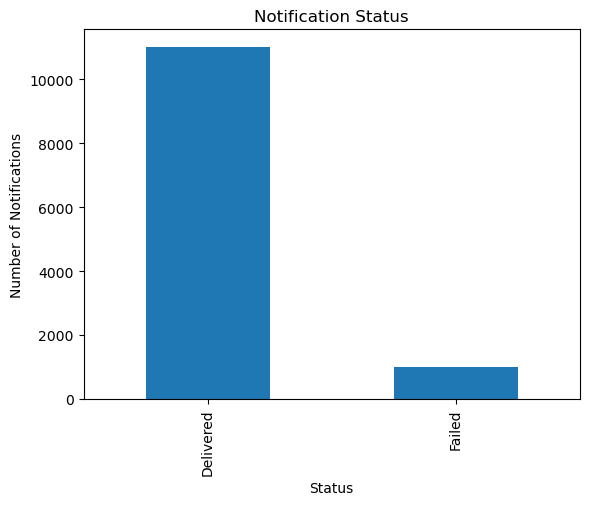

In [12]:
df["Status"].value_counts().plot(kind="bar")
plt.title("Notification Status")
plt.xlabel("Status")
plt.ylabel("Number of Notifications")
plt.show()

In [13]:
failure_rate = (
    (df["Status"] == "Failed").sum()
    / len(df)
) * 100

print(f"Failure Rate: {failure_rate:.2f}%")

Failure Rate: 8.28%


In [14]:
df[df["Status"] == "Failed"]["Failure_Reason"].value_counts()

Failure_Reason
Invalid Email           257
SMTP Timeout            211
Server Error            160
Mailbox Full            141
Network Error           113
Authentication Error    111
Name: count, dtype: int64

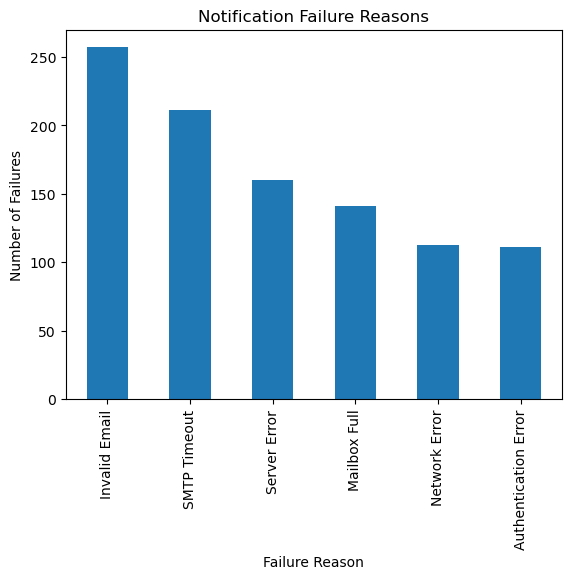

In [15]:
df[df["Status"] == "Failed"]["Failure_Reason"].value_counts().plot(
    kind="bar"
)

plt.title("Notification Failure Reasons")
plt.xlabel("Failure Reason")
plt.ylabel("Number of Failures")
plt.show()

In [16]:
service_failures = df[df["Status"] == "Failed"]["Service_Name"].value_counts()

print(service_failures)

Service_Name
Notification Service      215
Billing Service           210
Email Gateway             207
Authentication Service    195
Marketing Service         166
Name: count, dtype: int64


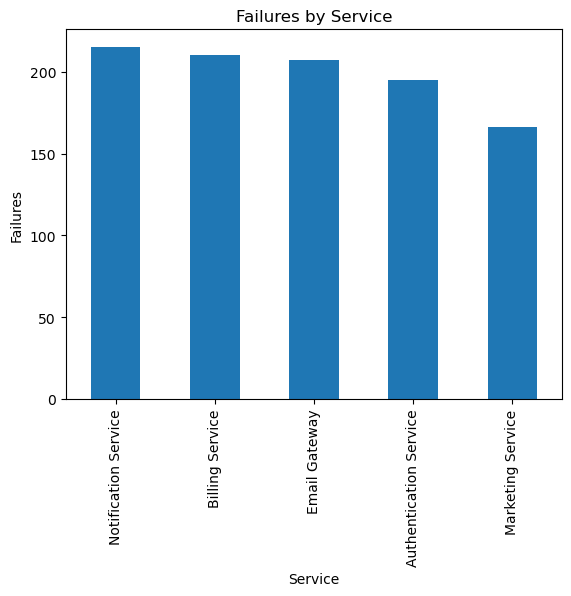

In [17]:
service_failures.plot(kind="bar")

plt.title("Failures by Service")
plt.xlabel("Service")
plt.ylabel("Failures")
plt.show()

In [18]:
notification_failures = df[df["Status"] == "Failed"]["Notification_Type"].value_counts()

print(notification_failures)

Notification_Type
Password Reset    215
Promotional       208
Invoice           202
Email             189
Alert             179
Name: count, dtype: int64


In [19]:
recipient_failures = df[df["Status"] == "Failed"]["Recipient_Type"].value_counts()

print(recipient_failures)

Recipient_Type
Admin       265
Vendor      258
Employee    235
Customer    235
Name: count, dtype: int64


In [20]:
df.groupby("Status")["Retry_Count"].mean()

Status
Delivered    0.059235
Failed       1.521652
Name: Retry_Count, dtype: float64

In [21]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [22]:
df["Hour"] = df["Timestamp"].dt.hour

In [23]:
df["Hour"].value_counts().sort_index()

Hour
0     497
1     519
2     480
3     540
4     475
5     537
6     492
7     457
8     491
9     486
10    511
11    480
12    501
13    518
14    506
15    536
16    477
17    516
18    454
19    500
20    516
21    485
22    534
23    492
Name: count, dtype: int64

In [24]:
hourly_failures = df[df["Status"] == "Failed"]["Hour"].value_counts().sort_index()

print(hourly_failures)

Hour
0     32
1     28
2     46
3     44
4     34
5     28
6     42
7     25
8     45
9     55
10    52
11    48
12    40
13    42
14    40
15    45
16    34
17    42
18    47
19    46
20    51
21    48
22    45
23    34
Name: count, dtype: int64


In [25]:
status_count = df["Status"].value_counts()

status_count

Status
Delivered    11007
Failed         993
Name: count, dtype: int64

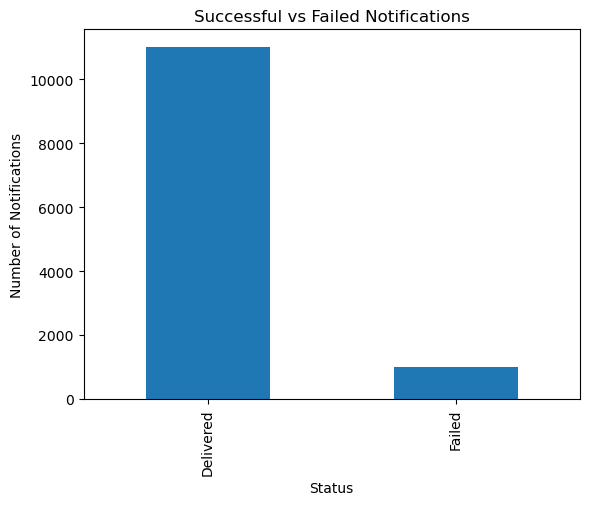

In [26]:
status_count.plot(kind="bar")

plt.title("Successful vs Failed Notifications")
plt.xlabel("Status")
plt.ylabel("Number of Notifications")

plt.show()

In [27]:
failure_reasons = df[df["Status"] == "Failed"]["Failure_Reason"].value_counts()

failure_reasons

Failure_Reason
Invalid Email           257
SMTP Timeout            211
Server Error            160
Mailbox Full            141
Network Error           113
Authentication Error    111
Name: count, dtype: int64

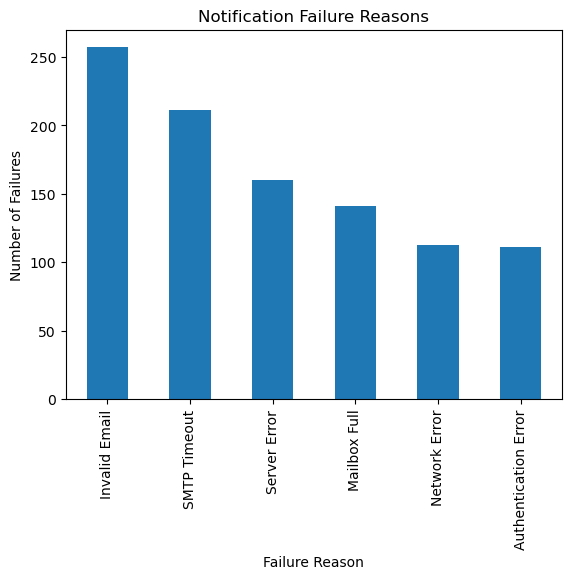

In [28]:
failure_reasons.plot(kind="bar")

plt.title("Notification Failure Reasons")
plt.xlabel("Failure Reason")
plt.ylabel("Number of Failures")

plt.show()

In [29]:
service_failures = (
    df[df["Status"] == "Failed"]["Service_Name"]
    .value_counts()
)

service_failures

Service_Name
Notification Service      215
Billing Service           210
Email Gateway             207
Authentication Service    195
Marketing Service         166
Name: count, dtype: int64

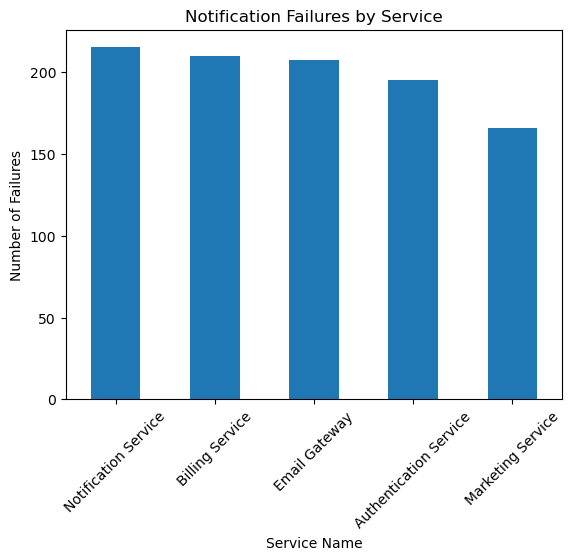

In [30]:
service_failures.plot(kind="bar")

plt.title("Notification Failures by Service")
plt.xlabel("Service Name")
plt.ylabel("Number of Failures")

plt.xticks(rotation=45)

plt.show()

In [31]:
notification_failures = (
    df[df["Status"] == "Failed"]["Notification_Type"]
    .value_counts()
)

notification_failures

Notification_Type
Password Reset    215
Promotional       208
Invoice           202
Email             189
Alert             179
Name: count, dtype: int64

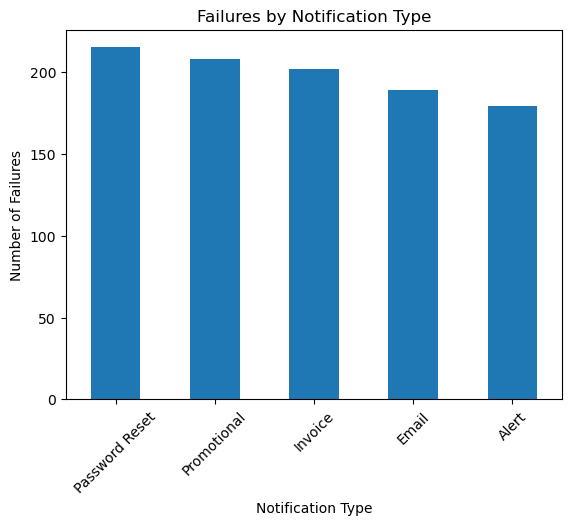

In [32]:
notification_failures.plot(kind="bar")

plt.title("Failures by Notification Type")
plt.xlabel("Notification Type")
plt.ylabel("Number of Failures")

plt.xticks(rotation=45)

plt.show()

In [33]:
delivery_time = df.groupby("Status")["Delivery_Time_ms"].mean()

delivery_time

Status
Delivered     994.253748
Failed       4439.148036
Name: Delivery_Time_ms, dtype: float64

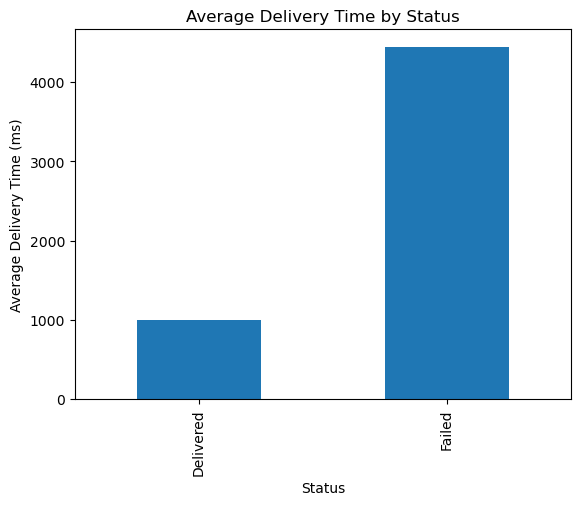

In [34]:
delivery_time.plot(kind="bar")

plt.title("Average Delivery Time by Status")
plt.xlabel("Status")
plt.ylabel("Average Delivery Time (ms)")

plt.show()